Keep this analyse, I can delete the othes

In [1]:
#THIS IS ON ALL THE DATA

from pathlib import Path
import numpy as np
import pandas as pd
from collections import defaultdict


from eelbrain import NDVar, UTS, Sensor, Case, Var, Factor, Dataset, save, plot, boosting

from ridge_regression_functions import (
    load_all_trials,
    split_trials_by_condition,
    WIN_OFFSET1,
    WIN_OFFSET2,
)

# 10 ms sampling → 100 Hz
SAMPLE_RATE = 100.0
TSTEP = 1.0 / SAMPLE_RATE  # 0.01 s

FRONTAL_MIDLINE = ['AFz','AF3','AF4','Fz','F1','F2','F3','F4','FC3','FC1','FC2','FC4','Cz','C3','C1','C2','C4']


In [4]:
import hashlib

def file_hash(path, algo="md5"):
    h = hashlib.new(algo)
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

h1 = file_hash(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast_and_slow\save\datasets\ds_sub-036_l13.pickle")
h2 = file_hash(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast_and_slow\ran10\datasets\ds_sub-036_l13.pickle")

print("hash1:", h1)
print("hash2:", h2)
print("equal:", h1 == h2)


hash1: 99df698fa2ffac7e05f532ff9f6c1148
hash2: 99df698fa2ffac7e05f532ff9f6c1148
equal: True


In [10]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp
from eelbrain import load


def analyze_all_decoders(
    trf_dir=r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\ran1\TRF"
):
    """
    Read all dec_eeg_to_ppd_sub-xxx_lyy.pickle decoders in `trf_dir`,
    extract correlation r and predictive power, and test whether r > 0.

    Returns
    -------
    df : pandas.DataFrame
        Columns: ['subject', 'load', 'r', 'var_explained']
    """
    trf_dir = Path(trf_dir)
    pattern = "dec_eeg_to_ppd_sub-*_l*.pickle"

    rows = []

    for fpath in trf_dir.glob(pattern):
        name = fpath.name
        # parse subject and load from filename: dec_eeg_to_ppd_sub-042_l13.pickle
        m = re.match(r"dec_eeg_to_ppd_sub-(\d+)_l(\d+)\.pickle", name)
        if not m:
            print(f"[skip] Could not parse subject/load from {name}")
            continue

        subj = int(m.group(1))
        load_val = int(m.group(2))

        # load BoostingResult
        dec = load.unpickle(fpath)

        # r: scalar (because y = ppd is 1D). Handle NDVar or float.
        try:
            r_val = float(dec.r)
        except Exception:
            r_val = float(np.asarray(dec.r.x).item())

        # predictive power: proportion_explained (0–1) → %
        var_exp = getattr(dec, "proportion_explained", None)
        if var_exp is not None:
            try:
                ve = float(var_exp) * 100.0
            except Exception:
                ve = float(np.asarray(var_exp.x).item()) * 100.0
        else:
            ve = np.nan

        rows.append({
            "subject": subj,
            "load": load_val,
            "r": r_val,
            "var_explained": ve,
            "file": name,
        })

    if not rows:
        print("No decoder files found; check TRF directory and naming.")
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    print("\nCollected decoder results:")
    print(df.sort_values(["subject", "load"]))

    # === Overall test: is mean r > 0 ? ===
    r_all = df["r"].values
    mean_r = r_all.mean()
    sd_r = r_all.std(ddof=1)
    n = len(r_all)

    # two-sided t-test vs 0, then convert to one-sided if mean_r > 0
    t_stat, p_two = ttest_1samp(r_all, popmean=0.0)
    if mean_r >= 0:
        p_one = p_two / 2.0
    else:
        p_one = 1.0 - p_two / 2.0  # if mean < 0, one-sided r > 0 is not interesting anyway

    var_explained_all = df["var_explained"].values
    mean_ve = var_explained_all.mean()
    sd_ve = var_explained_all.std(ddof=1)
    n_ve = len(var_explained_all)

    t_stat_ve, p_two_ve = ttest_1samp(var_explained_all, popmean=0.0)
    if mean_ve >= 0:
        p_one_ve = p_two_ve / 2.0
    else:
        p_one_ve = 1.0 - p_two_ve / 2.0

    print("\n=== Overall decoder r (EEG → ppd) ===")
    print(f"n = {n}")
    print(f"mean r = {mean_r:.4f}, SD = {sd_r:.4f}")
    print(f"t({n-1}) = {t_stat:.3f}, one-sided p (r>0) = {p_one:.3e}")

    # Also show overall predictive power
    if df["var_explained"].notna().any():
        mean_ve = df["var_explained"].mean()
        sd_ve = df["var_explained"].std(ddof=1)
        print(f"mean % variance explained = {mean_ve:.3f} ± {sd_ve:.3f}")
        print(f"t({n_ve-1}) = {t_stat_ve:.3f}, one-sided p (var explained > 0) = {p_one_ve:.3e}")

    # === Per-load tests ===
    print("\n=== Per-load tests (decoder r > 0) ===")
    for load_val in sorted(df["load"].unique()):
        sub_df = df[df["load"] == load_val]
        r_vals = sub_df["r"].values
        if len(r_vals) < 2:
            print(f"Load {load_val}: only {len(r_vals)} subject(s); skipping t-test.")
            continue
        mean_r_l = r_vals.mean()
        sd_r_l = r_vals.std(ddof=1)
        t_l, p2_l = ttest_1samp(r_vals, popmean=0.0)
        p1_l = p2_l / 2.0 if mean_r_l >= 0 else 1.0 - p2_l / 2.0
        print(f"  Load {load_val}: n = {len(r_vals)}, "
              f"mean r = {mean_r_l:.4f} ± {sd_r_l:.4f}, "
              f"t = {t_l:.3f}, one-sided p = {p1_l:.3e}")

    return df


In [2]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
from eelbrain import load


TRF_DIR = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast_and_slow\ran13\TRF")
DS_DIR  = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast_and_slow\ran13\datasets")

pattern = r"dec_eeg_to_ppd_sub-(\d+)_l(\d+)\.pickle"

rows = []

for dec_path in TRF_DIR.glob("dec_eeg_to_ppd_sub-*_l*.pickle"):
    m = re.match(pattern, dec_path.name)
    if not m:
        print(f"[skip] Could not parse: {dec_path.name}")
        continue

    subj = int(m.group(1))
    load_val = int(m.group(2))

    ds_path = DS_DIR / f"ds_sub-{subj:03d}_l{load_val:02d}.pickle"
    if not ds_path.exists():
        print(f"[skip] No dataset for {dec_path.name} at {ds_path}")
        continue

    dec = load.unpickle(dec_path)
    ds  = load.unpickle(ds_path)

    # True response (ppd); use dec.y if you want to be generic
    y = ds[dec.y] if dec.y in ds else ds['ppd']

    # ---------------------------------------------------------
    # Get predictions
    # ---------------------------------------------------------
    try:
        # Best case: we saved partition_results and can cross-predict
        if dec.partition_results:
            y_pred = dec.cross_predict(data=ds, scale='original', name='ppd_pred')
            y_for_stats = y  # both in original scale
        else:
            raise ValueError("No partition_results; trying y_pred")
    except Exception as e_cross:
        # Fallback: use stored y_pred (debug), at *normalized* scale
        if dec.y_pred is None:
            print(f"[skip] {dec_path.name}: no partition_results and no y_pred; "
                  f"can't reconstruct predictions.")
            continue

        # y_pred is on normalized scale; normalize y as well
        y_pred = dec.y_pred
        y_for_stats = (y - dec.y_mean) / dec.y_scale

    # ---------------------------------------------------------
    # Flatten & mask
    # ---------------------------------------------------------
    y_arr    = y_for_stats.x.ravel().astype(float)
    yhat_arr = y_pred.x.ravel().astype(float)

    mask = np.isfinite(y_arr) & np.isfinite(yhat_arr)
    if mask.sum() == 0:
        print(f"[skip] No finite samples for {dec_path.name}")
        continue

    yv    = y_arr[mask]
    yhatv = yhat_arr[mask]

    # ---------------------------------------------------------
    # Manual correlation
    # ---------------------------------------------------------
    r_manual = np.corrcoef(yv, yhatv)[0, 1]

    # ---------------------------------------------------------
    # Manual predictive power (variance explained)
    # ---------------------------------------------------------
    residual = yv - yhatv
    var_y   = np.var(yv, ddof=0)
    var_res = np.var(residual, ddof=0)
    prop_expl      = 1.0 - (var_res / var_y)         # 0–1
    prop_expl_pct  = 100.0 * prop_expl               # %

    # ---------------------------------------------------------
    # For comparison: model attributes
    # ---------------------------------------------------------
    try:
        r_model = float(dec.r)
    except Exception:
        r_model = float(np.asarray(dec.r.x).item())

    pe_attr = getattr(dec, "proportion_explained", None)
    if pe_attr is not None:
        try:
            pe_model = float(pe_attr) * 100.0
        except Exception:
            pe_model = float(np.asarray(pe_attr.x).item()) * 100.0
    else:
        pe_model = np.nan

    rows.append({
        "subject": subj,
        "load": load_val,
        "file": dec_path.name,
        "r_manual": r_manual,
        "r_model": r_model,
        "prop_expl_manual_%": prop_expl_pct,
        "prop_expl_attr_%": pe_model,
    })

df = pd.DataFrame(rows)
print(df.sort_values(["subject", "load"]))


KeyError: 'subject'

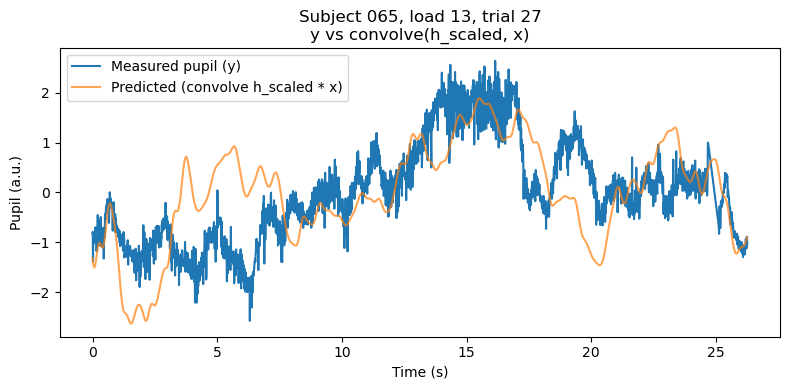

In [3]:
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from eelbrain import load, convolve

TRF_DIR = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast_and_slow\ran10\TRF")
DS_DIR  = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast_and_slow\ran10\datasets")

def zscore(ndvar):
    """Z-score an NDVar along the time dimension."""
    x = ndvar.x
    mean = np.nanmean(x, axis=-1, keepdims=True)
    std  = np.nanstd(x, axis=-1, keepdims=True)
    zscored_x = (x - mean) / std
    return zscored_x

def plot_trial_conv(subj: int, load_val: int, trial_idx: int = 0):
    """
    Plot measured pupil y vs convolve(h_scaled, x) for a single trial.

    subj      : subject number, e.g. 42
    load_val  : load number, e.g. 13
    trial_idx : index of trial/case to plot (0-based)
    """

    # ------------------------------------------------------------------
    # 1) Load decoder & dataset
    # ------------------------------------------------------------------
    dec_path = TRF_DIR / f"dec_eeg_to_ppd_sub-{subj:03d}_l{load_val:02d}.pickle"
    ds_path  = DS_DIR  / f"ds_sub-{subj:03d}_l{load_val:02d}.pickle"

    if not dec_path.exists():
        raise FileNotFoundError(f"No decoder file at {dec_path}")
    if not ds_path.exists():
        raise FileNotFoundError(f"No dataset file at {ds_path}")

    dec = load.unpickle(dec_path)
    ds  = load.unpickle(ds_path)

    # true response (ppd)
    y = ds[dec.y] if dec.y in ds else ds['ppd']

    # ------------------------------------------------------------------
    # 2) Prepare predictors x and kernel h_scaled
    # ------------------------------------------------------------------
    if dec.x is None:
        raise ValueError("dec.x is None – no predictor names stored in the BoostingResult")

    if isinstance(dec.x, str):
        x_names = [dec.x]
    else:
        x_names = list(dec.x)

    x_ndvars = [ds[name] for name in x_names]

    h = dec.h_scaled  # NDVar or tuple of NDVar
    if not isinstance(h, tuple):
        h = (h,)

    # ------------------------------------------------------------------
    # 3) Predict for all trials using convolution
    # ------------------------------------------------------------------
    y_pred_full = convolve(h, x_ndvars)  # NDVar with Case × Time (and maybe more dims)

    # ------------------------------------------------------------------
    # 4) Extract one trial (case) and align time
    # ------------------------------------------------------------------
    # assumes trial dimension is the 'case' dimension (the usual Eelbrain behavior)
    y_trial      = y.sub(case=trial_idx)
    y_pred_trial = y_pred_full.sub(case=trial_idx)

    y_trial_z = zscore(y_trial)
    y_pred_trial_z = zscore(y_pred_trial)

    # ------------------------------------------------------------------
    # 5) Plot
    # ------------------------------------------------------------------
    t = y_trial.time.times             # numpy array of time points
    y_vec    = y_trial_z.ravel()
    yhat_vec = y_pred_trial_z.ravel()

    plt.figure(figsize=(8, 4))
    plt.plot(t, y_vec,    label="Measured pupil (y)")
    plt.plot(t, yhat_vec, label="Predicted (convolve h_scaled * x)", alpha=0.7)
    plt.xlabel("Time (s)")
    plt.ylabel("Pupil (a.u.)")
    plt.title(f"Subject {subj:03d}, load {load_val}, trial {trial_idx}\n"
              f"y vs convolve(h_scaled, x)")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Example usage:
plot_trial_conv(subj=65, load_val=13, trial_idx=27)

In [3]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
from eelbrain import load, convolve


TRF_DIR = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast\ran12\TRF")
DS_DIR  = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast\ran12\datasets")

pattern = r"dec_eeg_to_ppd_sub-(\d+)_l(\d+)\.pickle"

rows = []

for dec_path in TRF_DIR.glob("dec_eeg_to_ppd_sub-*_l*.pickle"):
    m = re.match(pattern, dec_path.name)
    if not m:
        print(f"[skip] Could not parse: {dec_path.name}")
        continue

    subj = int(m.group(1))
    load_val = int(m.group(2))

    ds_path = DS_DIR / f"ds_sub-{subj:03d}_l{load_val}.pickle"
    if not ds_path.exists():
        print(f"[skip] No dataset for {dec_path.name} at {ds_path}")
        continue

    # ---------------------------------------------------------
    # 1) Load decoder & dataset
    # ---------------------------------------------------------
    dec = load.unpickle(dec_path)
    ds  = load.unpickle(ds_path)

    # true response
    y = ds[dec.y] if dec.y in ds else ds['ppd']

    # predictors for convolve
    # dec.x can be None, str or tuple/list of names
    if dec.x is None:
        print(f"[skip] {dec_path.name}: dec.x is None (no predictors stored).")
        continue
    elif isinstance(dec.x, str):
        x_names = [dec.x]
    else:
        x_names = list(dec.x)

    x_ndvars = [ds[name] for name in x_names]

    # kernel in *original* scale
    h = dec.h_scaled   # NDVar or tuple of NDVar
    if not isinstance(h, tuple):
        h = (h,)

    # ---------------------------------------------------------
    # 2) Predict using linear convolution
    #    y_pred has the same y-dims and a time dim determined by
    #    x + kernel
    # ---------------------------------------------------------
    y_pred = convolve(h, x_ndvars)

    y_c = y
    y_pred_c = y_pred

    # ---------------------------------------------------------
    # 4) Flatten and mask NaNs
    # ---------------------------------------------------------
    y_arr    = y_c.x.ravel().astype(float)
    yhat_arr = y_pred_c.x.ravel().astype(float)

    mask = np.isfinite(y_arr) & np.isfinite(yhat_arr)
    if mask.sum() == 0:
        print(f"[skip] No finite samples for {dec_path.name}")
        continue

    yv    = y_arr[mask]
    yhatv = yhat_arr[mask]

    # ---------------------------------------------------------
    # 5) Manual correlation
    # ---------------------------------------------------------
    r_manual = np.corrcoef(yv, yhatv)[0, 1]

    # ---------------------------------------------------------
    # 6) Manual predictive power (variance explained)
    #     (on whatever scale we used for y and y_pred – here original)
    # ---------------------------------------------------------
    residual = yv - yhatv
    var_y   = np.var(yv, ddof=0)
    var_res = np.var(residual, ddof=0)
    prop_expl      = 1.0 - (var_res / var_y)      # 0–1
    prop_expl_pct  = 100.0 * prop_expl           # %

    # ---------------------------------------------------------
    # 7) Model attributes for comparison
    # ---------------------------------------------------------
    try:
        r_model = float(dec.r)
    except Exception:
        r_model = float(np.asarray(dec.r.x).item())

    pe_attr = getattr(dec, "proportion_explained", None)
    if pe_attr is not None:
        try:
            pe_model = float(pe_attr) * 100.0
        except Exception:
            pe_model = float(np.asarray(pe_attr.x).item()) * 100.0
    else:
        pe_model = np.nan

    rows.append({
        "subject": subj,
        "load": load_val,
        "file": dec_path.name,
        "r_manual_convolve": r_manual,
        "r_model": r_model,
        "prop_expl_manual_%": prop_expl_pct,
        "prop_expl_attr_%": pe_model,
    })

df = pd.DataFrame(rows)
print(df.sort_values(["subject", "load"]))


    subject  load                               file  r_manual_convolve  \
0        33    13  dec_eeg_to_ppd_sub-033_l13.pickle           0.315202   
1        34    13  dec_eeg_to_ppd_sub-034_l13.pickle           0.269334   
2        36    13  dec_eeg_to_ppd_sub-036_l13.pickle           0.284883   
3        38    13  dec_eeg_to_ppd_sub-038_l13.pickle           0.407849   
4        39    13  dec_eeg_to_ppd_sub-039_l13.pickle           0.401347   
5        40    13  dec_eeg_to_ppd_sub-040_l13.pickle           0.462762   
6        41    13  dec_eeg_to_ppd_sub-041_l13.pickle           0.379046   
7        42    13  dec_eeg_to_ppd_sub-042_l13.pickle           0.371849   
8        43    13  dec_eeg_to_ppd_sub-043_l13.pickle           0.314748   
9        44    13  dec_eeg_to_ppd_sub-044_l13.pickle           0.329862   
10       45    13  dec_eeg_to_ppd_sub-045_l13.pickle           0.331130   
11       47    13  dec_eeg_to_ppd_sub-047_l13.pickle           0.480525   
12       48    13  dec_ee

In [2]:
df.to_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast_and_slow\ran10\decoder_all2.csv")

In [25]:
#%matplotlib qt
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
# Use Arial everywhere (falls back if not available)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 12,          # base font size
    "axes.titlesize": 16,     # figure/axes titles
    "axes.labelsize": 13,     # x/y labels
    "legend.fontsize": 11,    # legend text
    "xtick.labelsize": 11,    # tick labels
    "ytick.labelsize": 11,
    "figure.titlesize": 18,   # suptitle
})

In [18]:
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

# Make a clean copy without NaNs in the relevant columns
cols = ["r_manual_convolve", "r_model"]
df_hist = df.dropna(subset=cols).copy()

titles = [
    "Decoder correlation",
    "Decoder test correlation",
]

xlabels = [
    "r_dec",
    "r_test",
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, col, title, xlabel in zip(axes, cols, titles, xlabels):
    vals = df_hist[col].values

    # Histogram (counts, like in your ridge code)
    ax.hist(vals, bins=30, alpha=0.6, density=True)

    # Fit normal distribution
    mu, sigma = norm.fit(vals)

    # X range for the curve (clamp to a nice window)
    x_min, x_max = vals.min(), vals.max()
    # You can override these if you want fixed ranges, e.g. for correlations:
    if "r" in col:
        x_min, x_max = -0.4, 0.6
    x = np.linspace(x_min, x_max, 200)

    # Normal PDF (not rescaled, just like your ridge plot)
    pdf = norm.pdf(x, mu, sigma)
    ax.plot(x, pdf, linewidth=2)

    # Reference at 0
    ax.axvline(0, linestyle="--", color="k")

    ax.set_title(f"{title}\nμ={mu:.3f}, σ={sigma:.3f}")
    ax.set_xlabel(xlabel)
    if ax == axes[0]:
        ax.set_ylabel("Density (# subjects)")
    ax.grid(True)

plt.tight_layout()
plt.show()


In [31]:
# if df is already your DataFrame
col_means = df.mean(numeric_only=True)
print(col_means)


subject               63.880000
load                  13.000000
r_manual_convolve      0.286688
r_model                0.093733
prop_expl_manual_%     5.150044
prop_expl_attr_%       1.294874
dtype: float64


In [11]:
trf_dir2=r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast_and_slow\ran10\TRF"
df_dec2 = analyze_all_decoders(trf_dir=trf_dir2)
num_below_zero = (df_dec2['r'] < 0).sum()
print(num_below_zero)



Collected decoder results:
    subject  load         r  var_explained                               file
0        33    13  0.062625      -0.075419  dec_eeg_to_ppd_sub-033_l13.pickle
1        34    13  0.192570       3.704323  dec_eeg_to_ppd_sub-034_l13.pickle
2        36    13  0.002705      -0.504686  dec_eeg_to_ppd_sub-036_l13.pickle
3        38    13 -0.019668      -0.501484  dec_eeg_to_ppd_sub-038_l13.pickle
4        39    13  0.282845       7.591730  dec_eeg_to_ppd_sub-039_l13.pickle
5        40    13  0.103822       0.887965  dec_eeg_to_ppd_sub-040_l13.pickle
6        41    13  0.070248       0.127733  dec_eeg_to_ppd_sub-041_l13.pickle
7        42    13  0.055680       0.166031  dec_eeg_to_ppd_sub-042_l13.pickle
8        43    13  0.149263       2.217250  dec_eeg_to_ppd_sub-043_l13.pickle
9        44    13  0.054125       0.291586  dec_eeg_to_ppd_sub-044_l13.pickle
10       45    13 -0.005594      -0.843269  dec_eeg_to_ppd_sub-045_l13.pickle
11       47    13  0.022420      -1.

In [22]:
from pathlib import Path
import re
import numpy as np
import eelbrain
from matplotlib import pyplot as plt

TRF_DIR = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast_and_slow\ran10\TRF")

cases = []
for f in TRF_DIR.glob("dec_eeg_to_ppd_sub-*_l*.pickle"):
    m = re.match(r"dec_eeg_to_ppd_sub-(\d+)_l(\d+)\.pickle", f.name)
    if not m:
        continue
    subj = f"S{int(m.group(1)):03d}"
    load_val = int(m.group(2))

    dec = eelbrain.load.unpickle(f)

    trf = dec.h_scaled                     # NDVar(sensor × time): decoder weights
    r_val = float(dec.r)                   # scalar correlation
    ve = float(dec.proportion_explained) * 100  # % variance explained

    cases.append([subj, load_val, trf, r_val, ve])

dataset_dec = eelbrain.Dataset.from_caselist(
    ['subject', 'load', 'trf_dec', 'r', 'var_explained'],
    cases,
    random='subject'
)

print(f"Loaded {len(dataset_dec)} decoder results.")


Loaded 5 decoder results.


In [20]:
import numpy as np

rs = np.array(dataset_dec['r'])
print(f"Decoder r: mean={rs.mean():.4f}, SD={rs.std(ddof=1):.4f}, n={len(rs)}")

plt.figure()
plt.hist(rs, bins=10, edgecolor='black')
plt.xlabel("decoder r (EEG → pupil)")
plt.ylabel("count")
plt.title("Distribution of decoder r across subjects")
plt.show()


Decoder r: mean=0.0995, SD=0.0932, n=52


<Figure size 640x480 with 0 Axes>

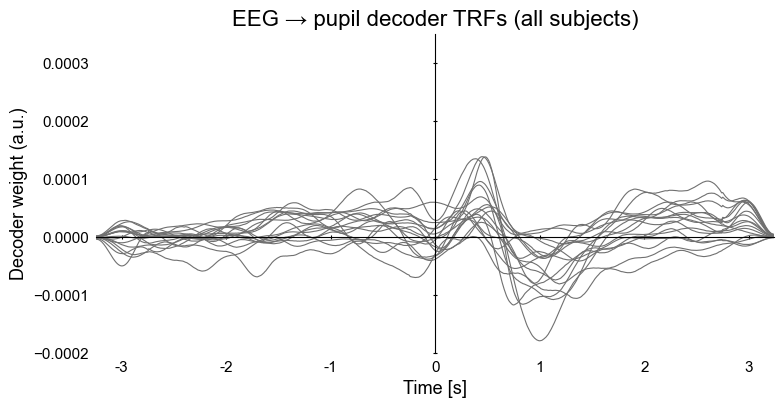

In [30]:
trf_all_dec = dataset_dec['trf_dec']  # NDVar(case × sensor × time)

plt.figure()
pb_dec = eelbrain.plot.Butterfly(
    trf_all_dec,
    vmin=-0.0002, vmax=0.00035,   # adjust to your scale if needed
    linewidth=0.8,
    color='#707070',
    frame='t',
    ylabel="Decoder weight (a.u.)", # one per sensor, averaged over subjects
    clip=True,
)
plt.title("EEG → pupil decoder TRFs (all subjects)")

plt.show()


<Figure size 640x480 with 0 Axes>

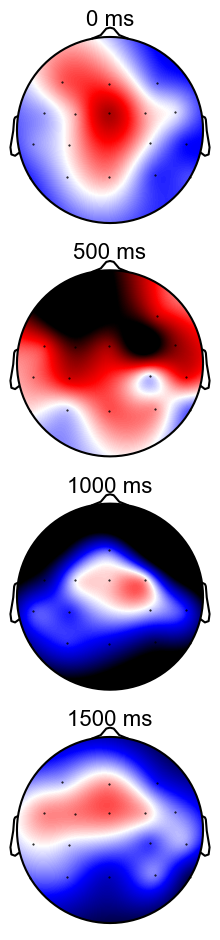

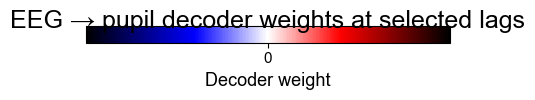

In [32]:
# mean over case dimension: sensor × time
trf_mean_dec = trf_all_dec.mean('case')

# choose times where you expect strong decoder weights
times_topo = [0, 0.5, 1.0, 1.5]  # seconds
labels_topo = [f"{int(t*1000)} ms" for t in times_topo]

# build list of sensor NDVars, one per time
slices = [trf_mean_dec.sub(time=t) for t in times_topo]

# one figure with 3 topomaps
plt.figure()
p_topo_dec = eelbrain.plot.Topomap(
    slices,
    axtitle=labels_topo,
    vmax=0.0001,          # same as butterfly vmin/vmax
    clip='circle',
)
p_topo_dec.plot_colorbar(
    label="Decoder weight",
    ticks={0.0002: '+', -0.0002: '-', 0: '0'}
)
plt.suptitle("EEG → pupil decoder weights at selected lags")
plt.show()


<Figure size 640x480 with 0 Axes>

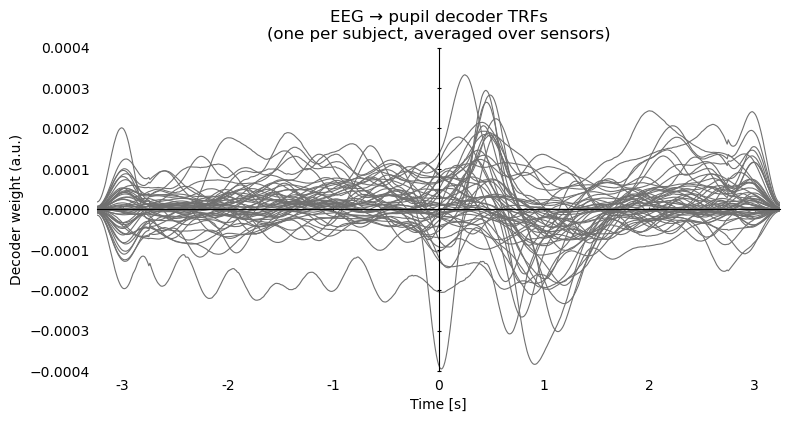

In [8]:
# ------------------------------------------------------------
# 1) TRF per subject (average over sensors)
# ------------------------------------------------------------
trf_subj = trf_all_dec.mean('sensor')  # NDVar: case × time

plt.figure()
pb_subj = eelbrain.plot.Butterfly(
    trf_subj,
    linewidth=0.8,
    color='#707070',
    frame='t',
    clip=True,
)
plt.title("EEG → pupil decoder TRFs\n(one per subject, averaged over sensors)")
plt.ylabel("Decoder weight (a.u.)")
plt.show()


C:\Users\cdd\AppData\Local\Temp\ipykernel_28940\4128507855.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


<Figure size 640x480 with 0 Axes>

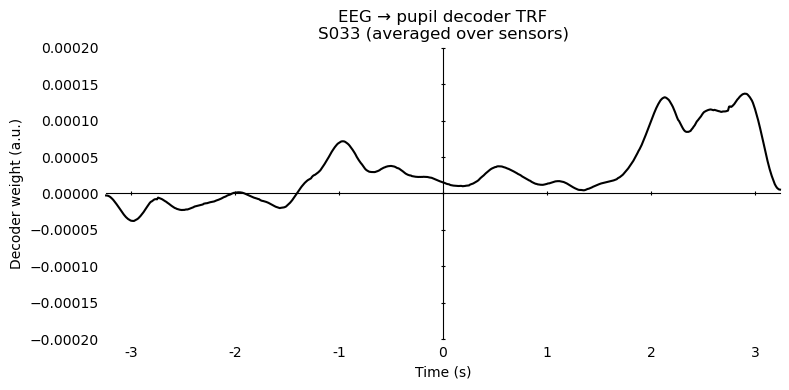

<Figure size 640x480 with 0 Axes>

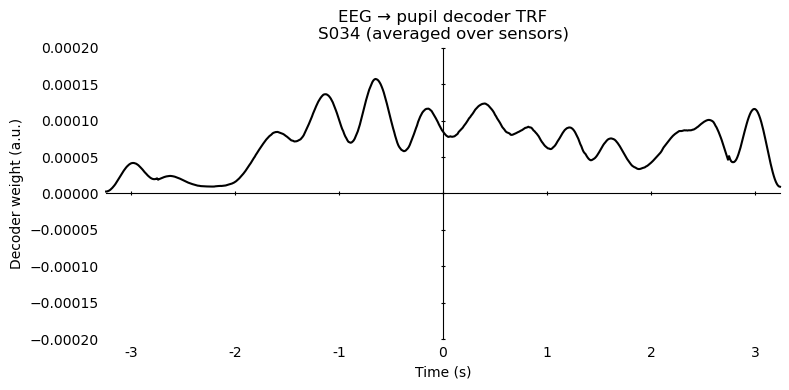

<Figure size 640x480 with 0 Axes>

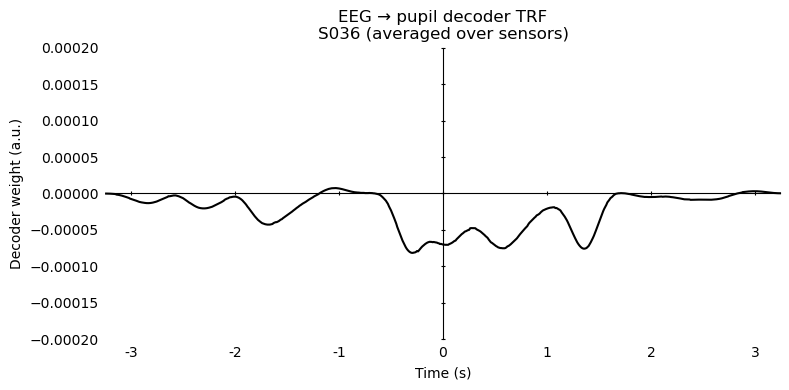

<Figure size 640x480 with 0 Axes>

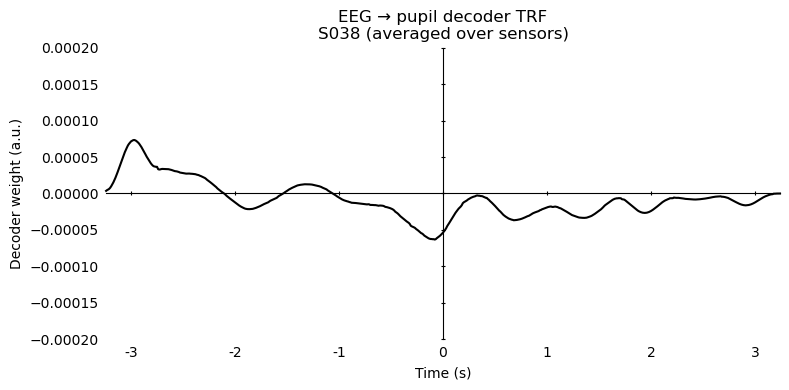

<Figure size 640x480 with 0 Axes>

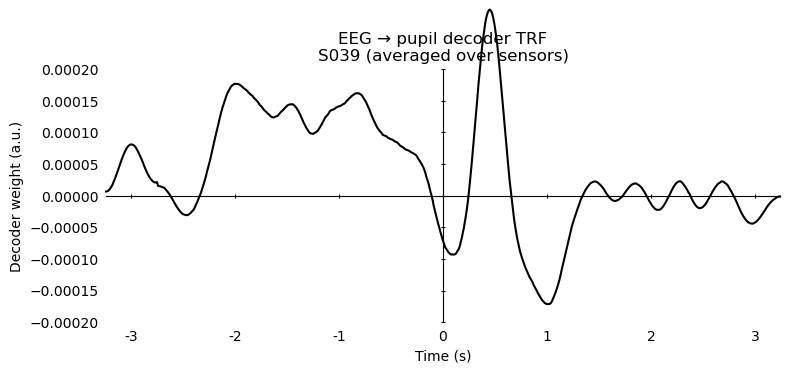

<Figure size 640x480 with 0 Axes>

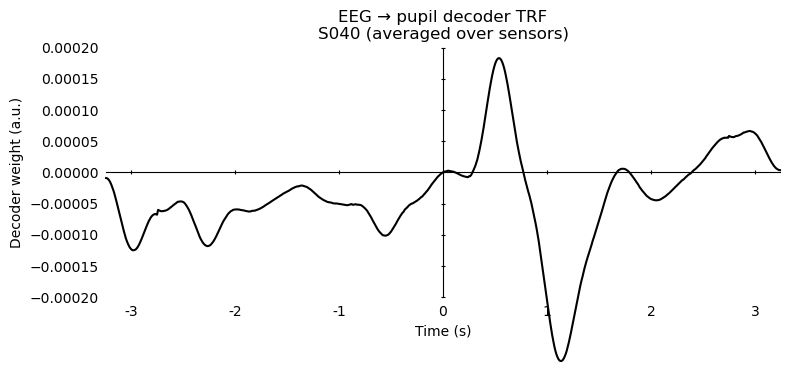

<Figure size 640x480 with 0 Axes>

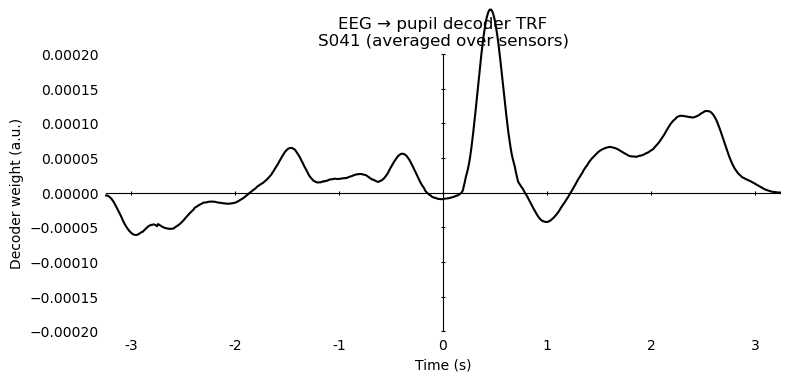

<Figure size 640x480 with 0 Axes>

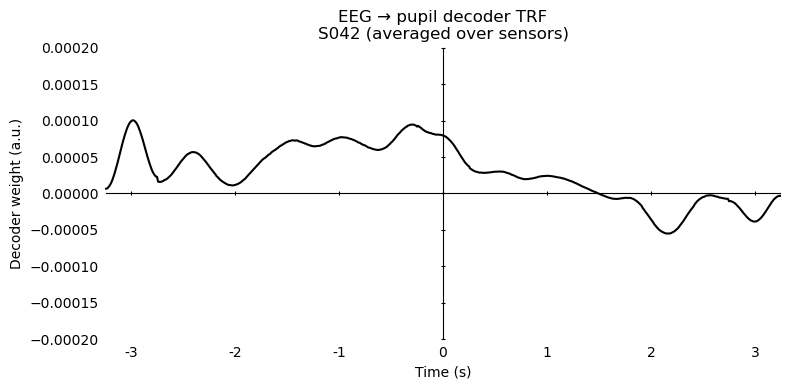

<Figure size 640x480 with 0 Axes>

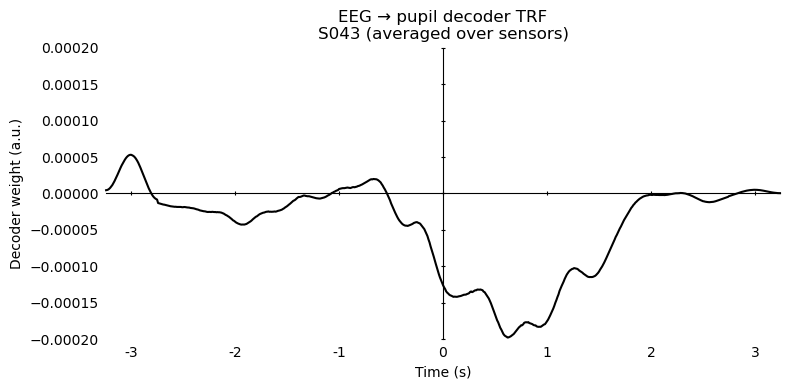

<Figure size 640x480 with 0 Axes>

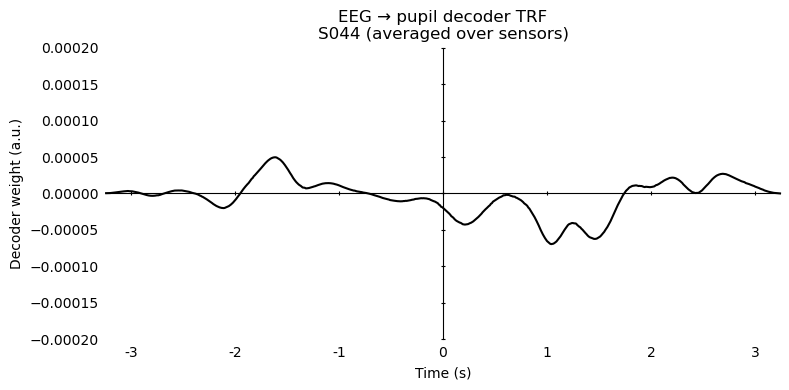

<Figure size 640x480 with 0 Axes>

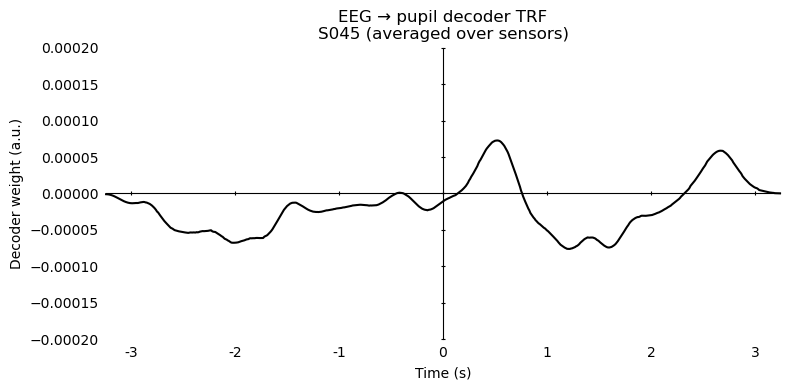

<Figure size 640x480 with 0 Axes>

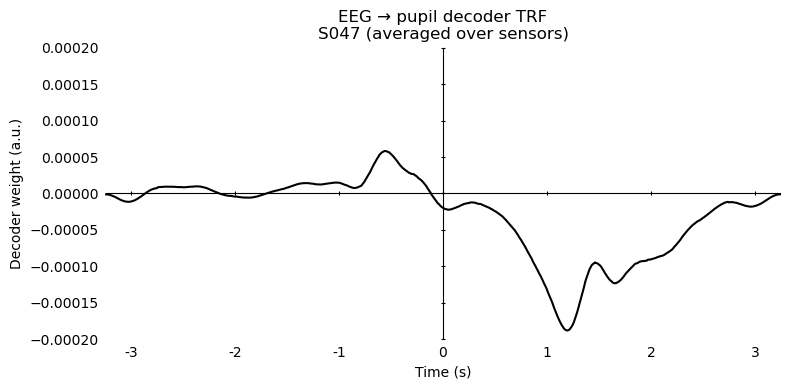

<Figure size 640x480 with 0 Axes>

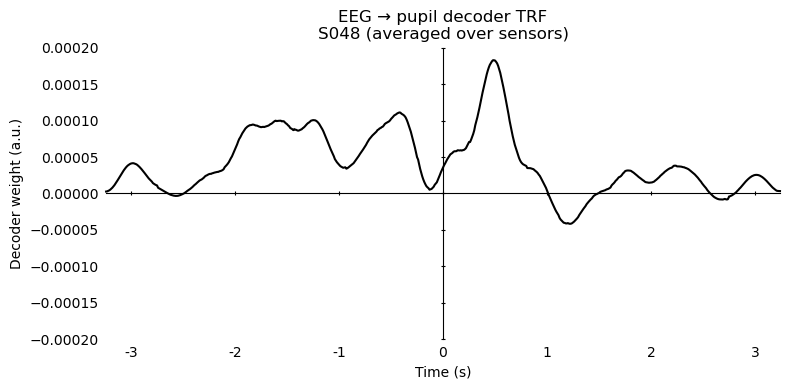

<Figure size 640x480 with 0 Axes>

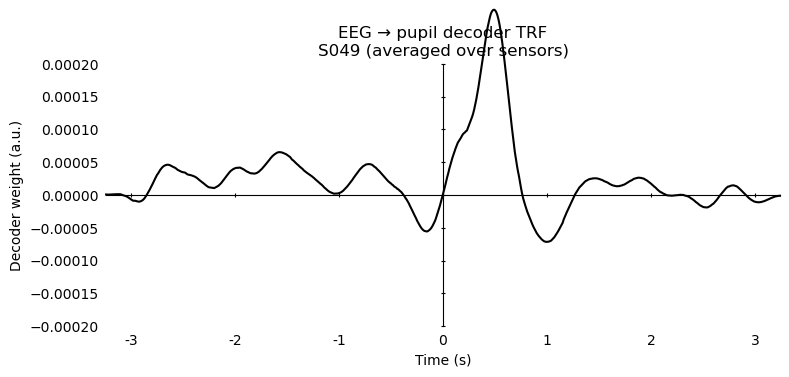

<Figure size 640x480 with 0 Axes>

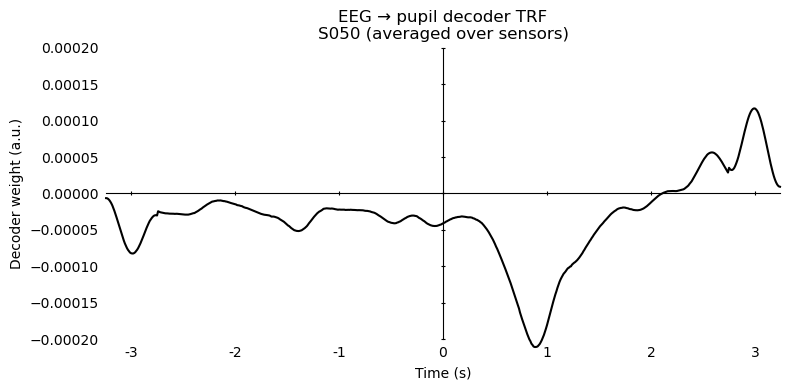

<Figure size 640x480 with 0 Axes>

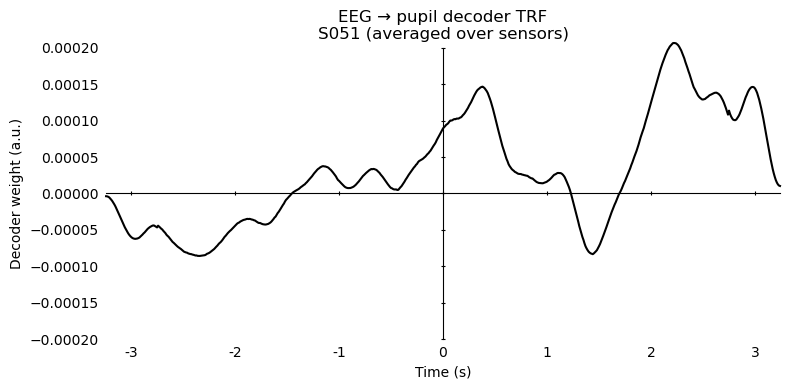

<Figure size 640x480 with 0 Axes>

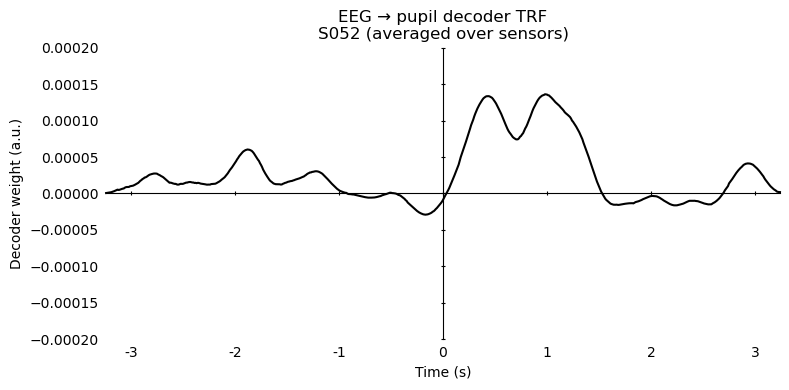

<Figure size 640x480 with 0 Axes>

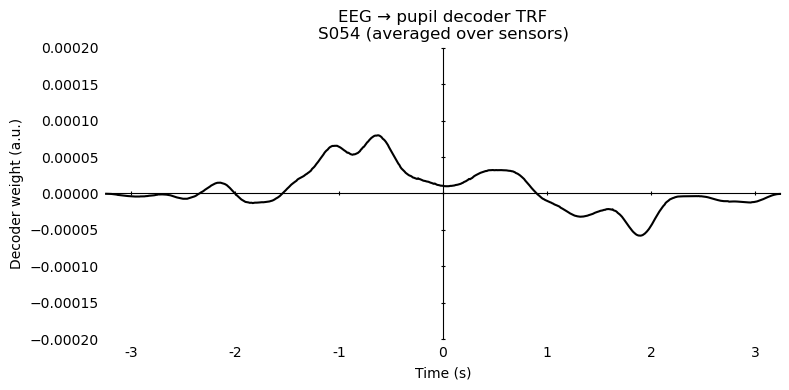

<Figure size 640x480 with 0 Axes>

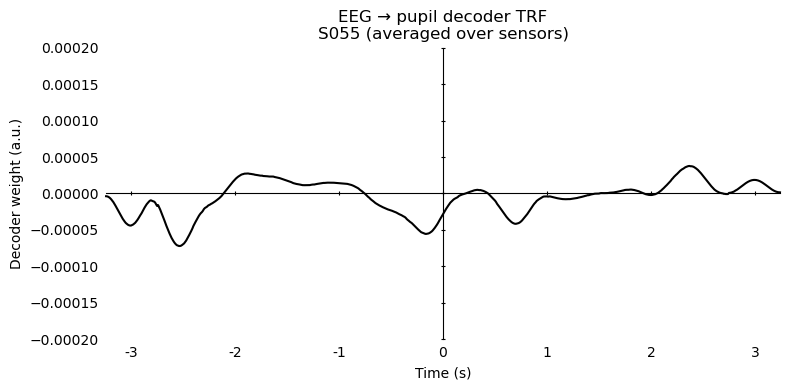

<Figure size 640x480 with 0 Axes>

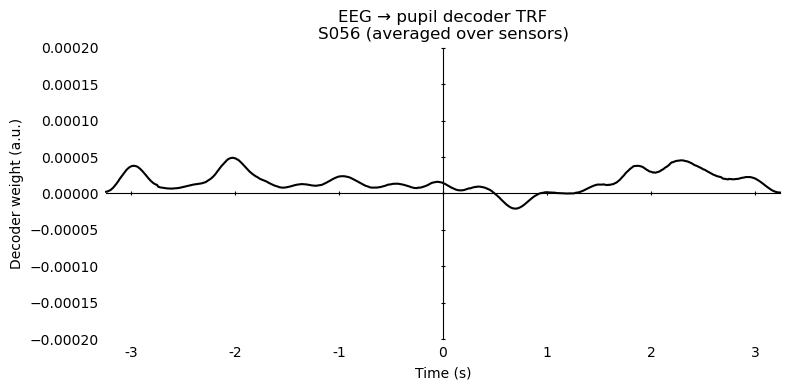

<Figure size 640x480 with 0 Axes>

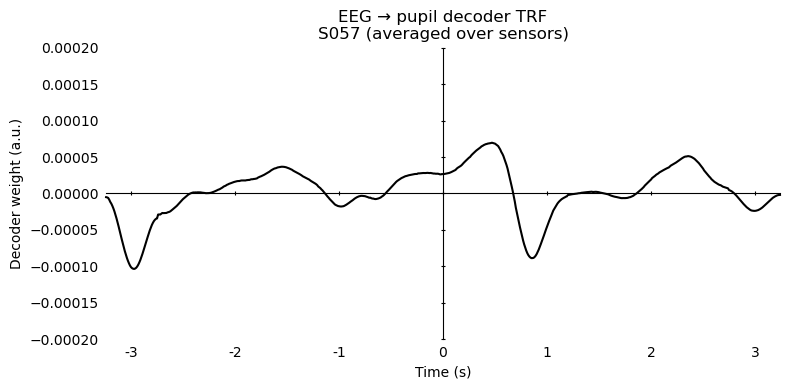

<Figure size 640x480 with 0 Axes>

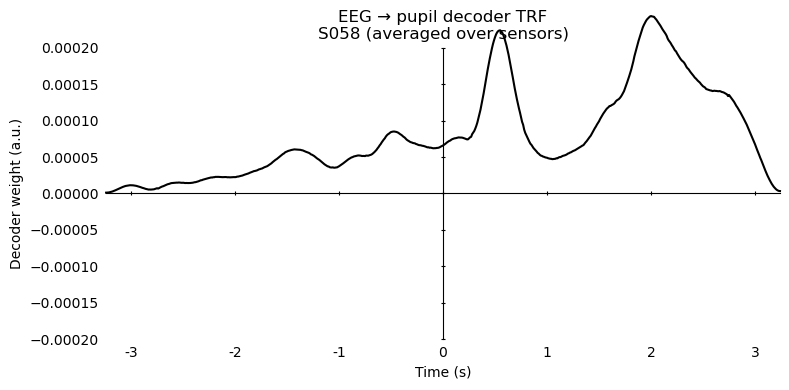

<Figure size 640x480 with 0 Axes>

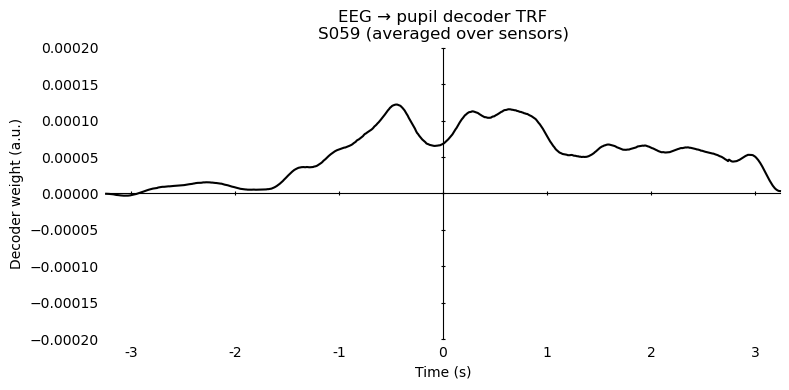

<Figure size 640x480 with 0 Axes>

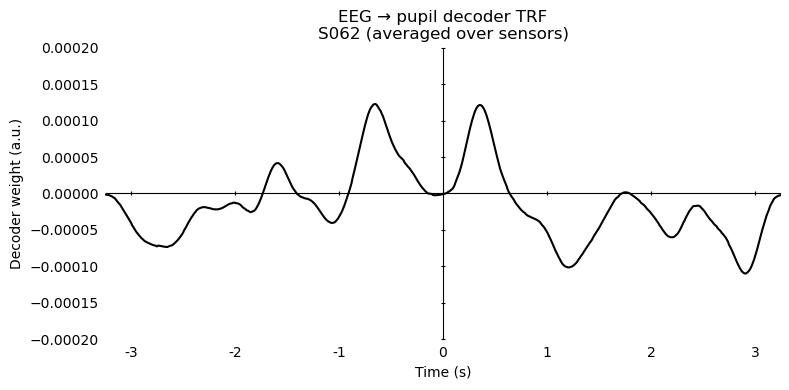

<Figure size 640x480 with 0 Axes>

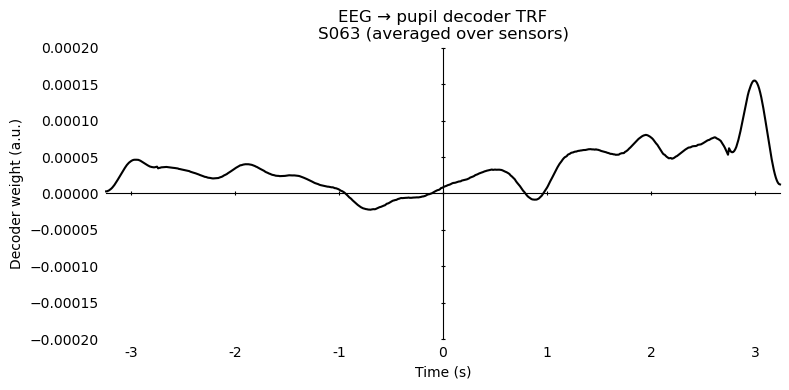

<Figure size 640x480 with 0 Axes>

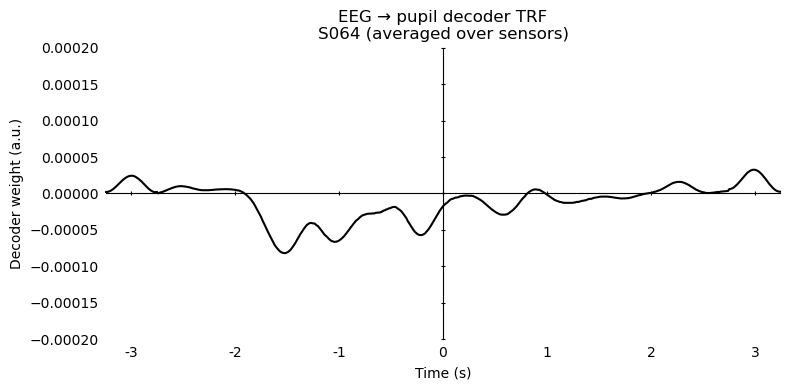

<Figure size 640x480 with 0 Axes>

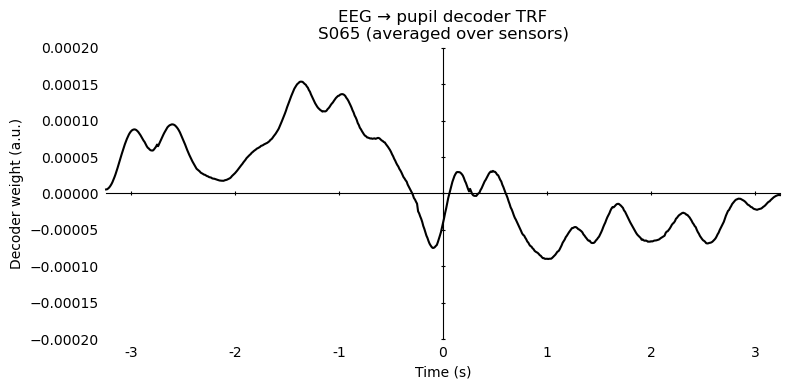

<Figure size 640x480 with 0 Axes>

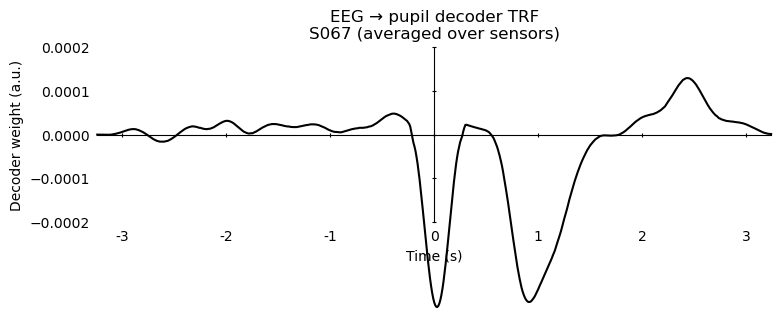

<Figure size 640x480 with 0 Axes>

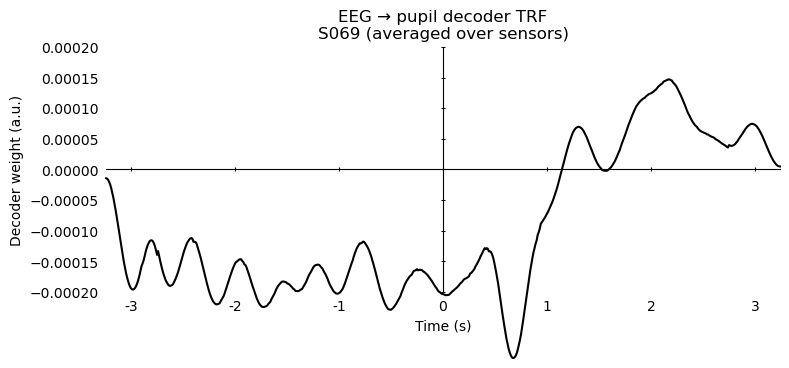

<Figure size 640x480 with 0 Axes>

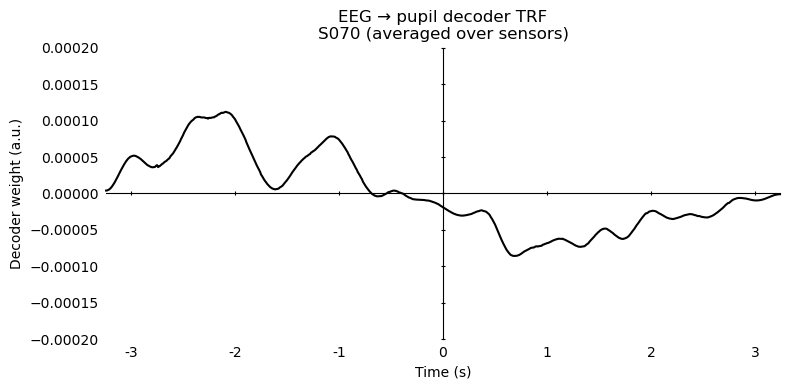

<Figure size 640x480 with 0 Axes>

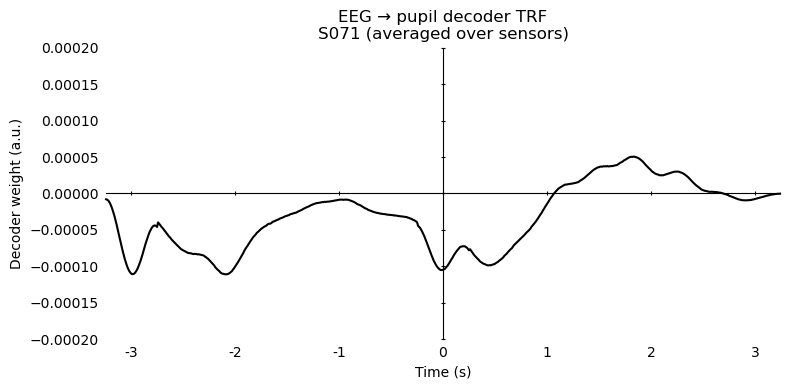

<Figure size 640x480 with 0 Axes>

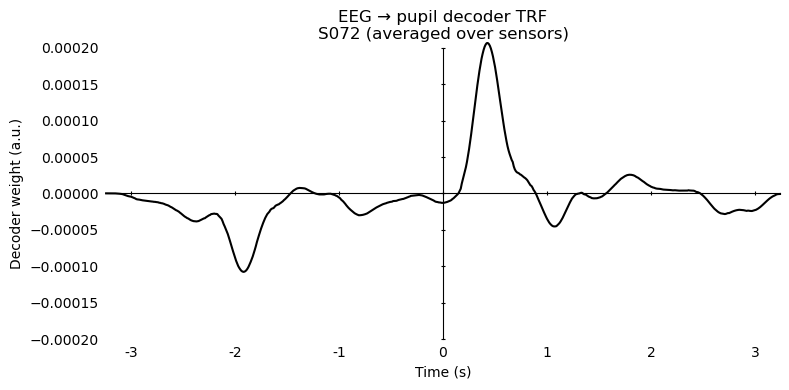

<Figure size 640x480 with 0 Axes>

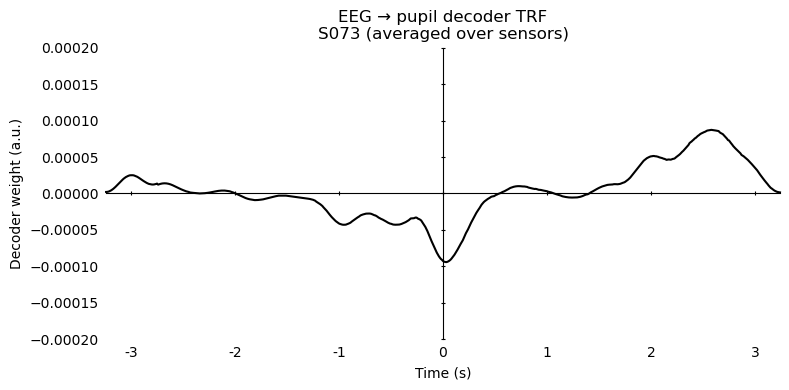

<Figure size 640x480 with 0 Axes>

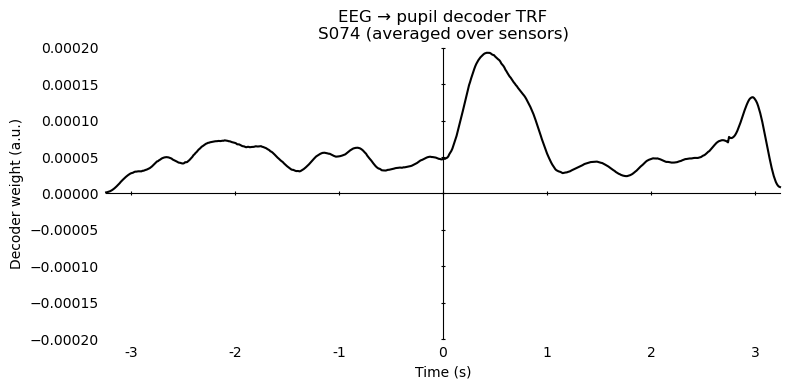

<Figure size 640x480 with 0 Axes>

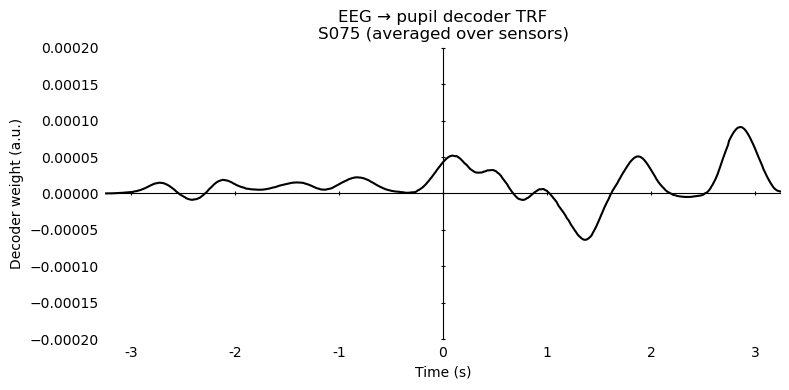

<Figure size 640x480 with 0 Axes>

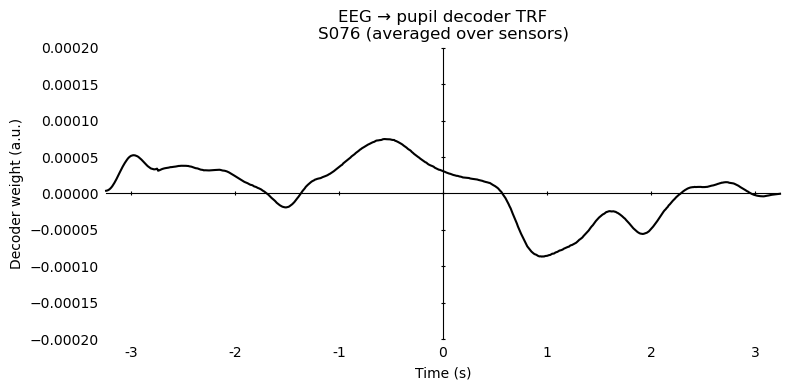

<Figure size 640x480 with 0 Axes>

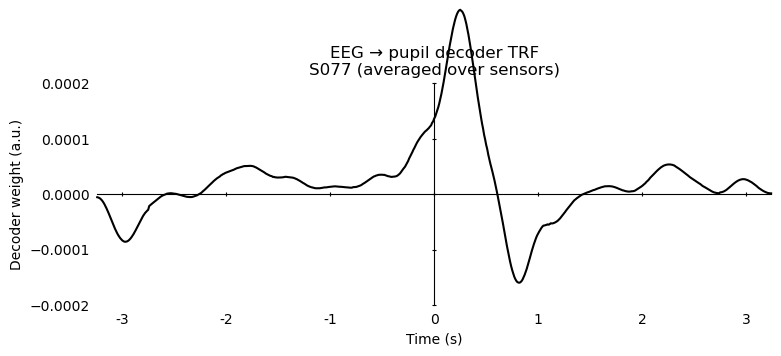

<Figure size 640x480 with 0 Axes>

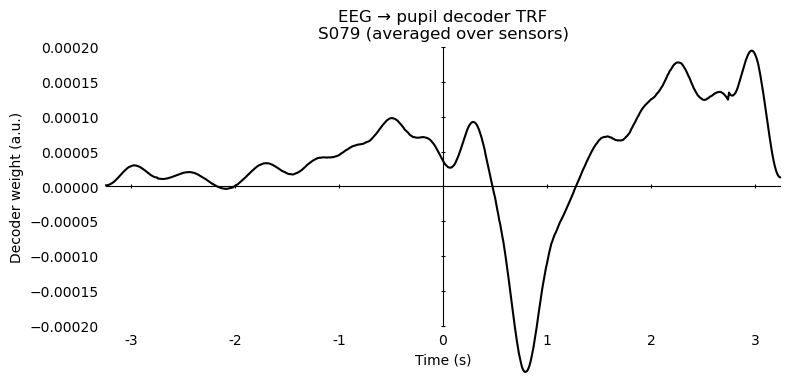

<Figure size 640x480 with 0 Axes>

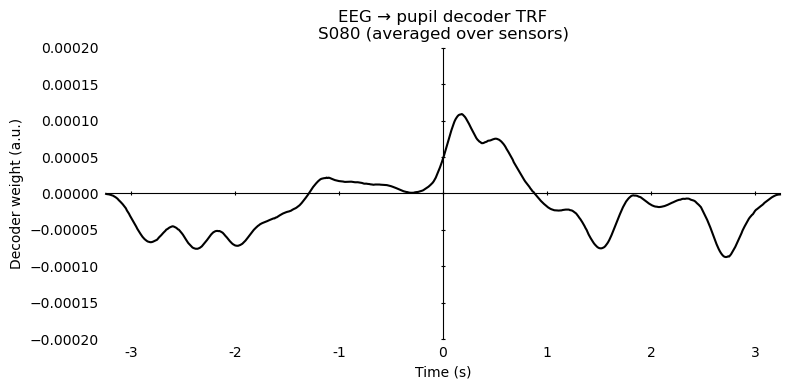

<Figure size 640x480 with 0 Axes>

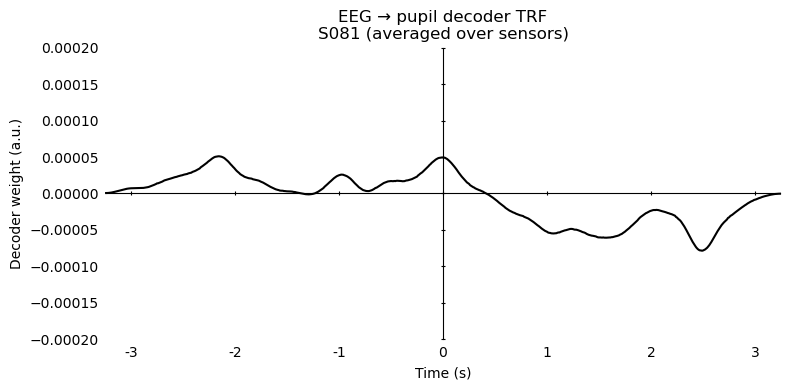

<Figure size 640x480 with 0 Axes>

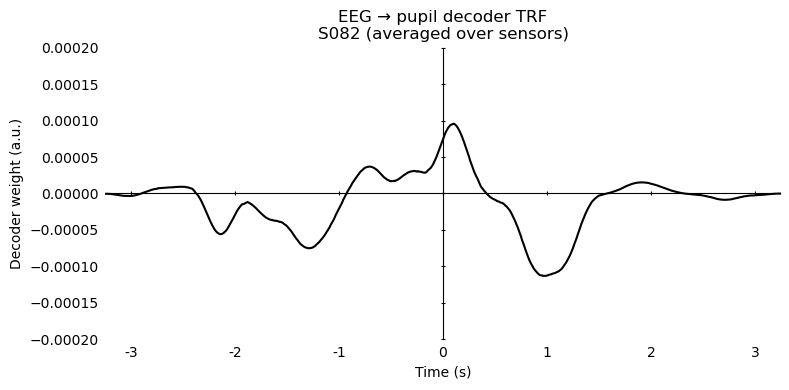

<Figure size 640x480 with 0 Axes>

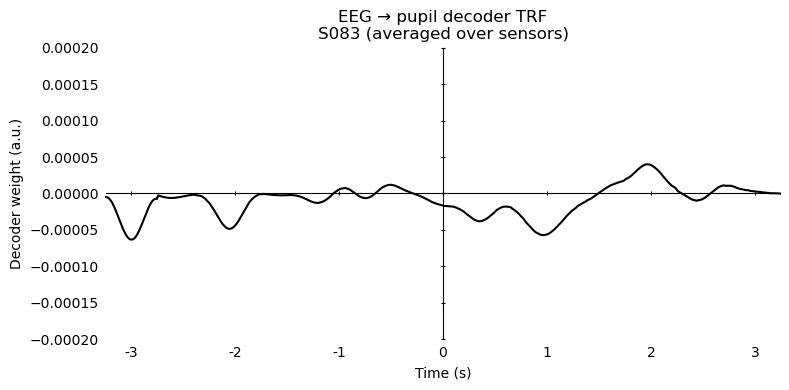

<Figure size 640x480 with 0 Axes>

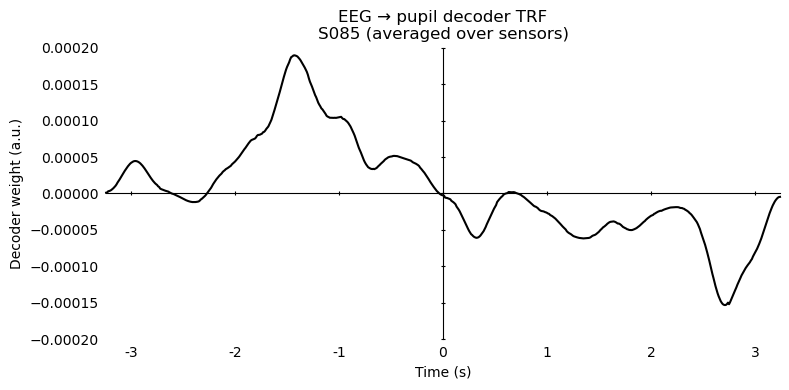

<Figure size 640x480 with 0 Axes>

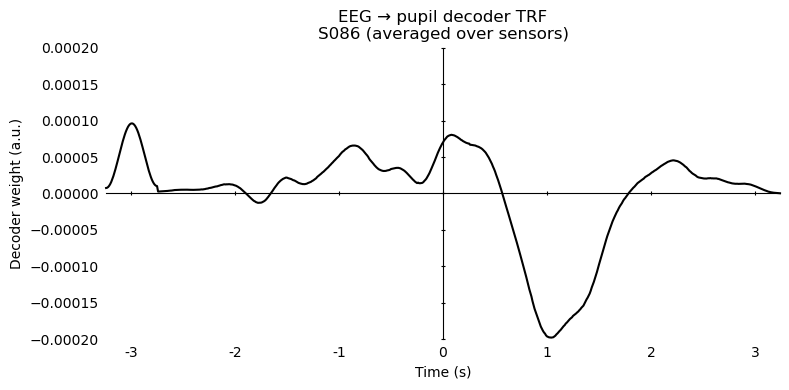

<Figure size 640x480 with 0 Axes>

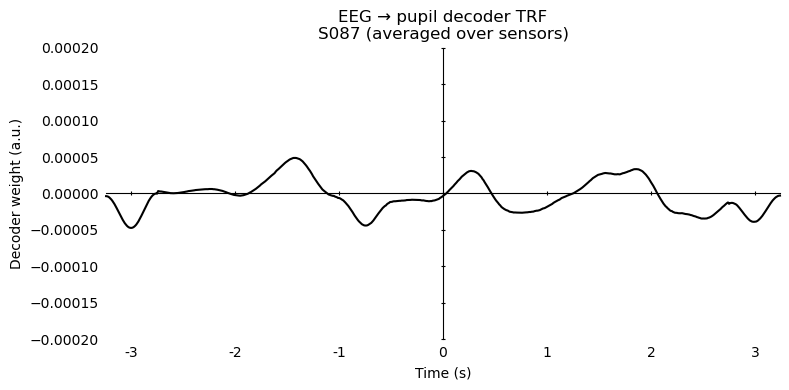

<Figure size 640x480 with 0 Axes>

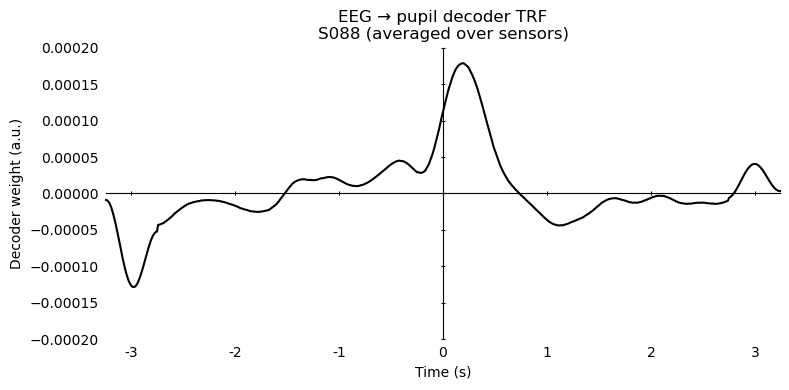

<Figure size 640x480 with 0 Axes>

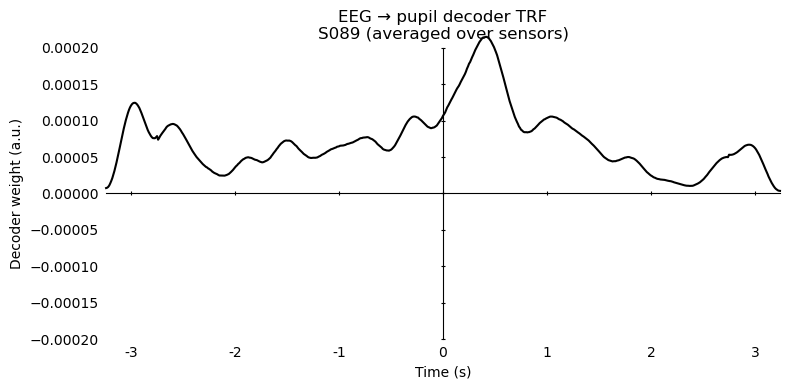

<Figure size 640x480 with 0 Axes>

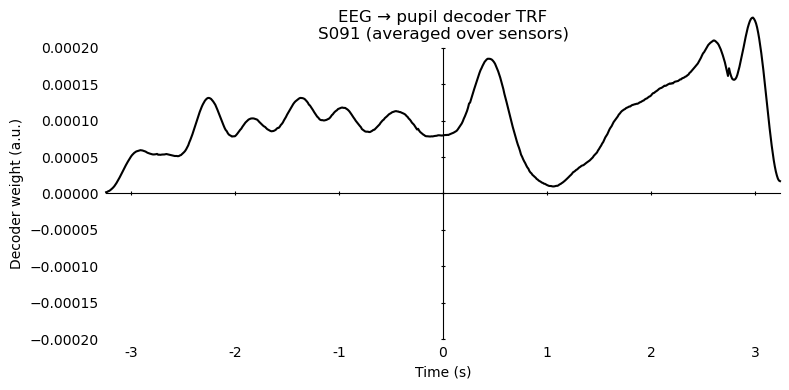

<Figure size 640x480 with 0 Axes>

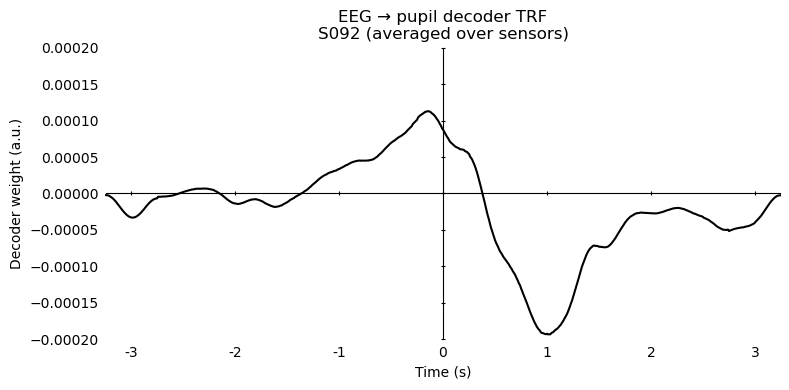

<Figure size 640x480 with 0 Axes>

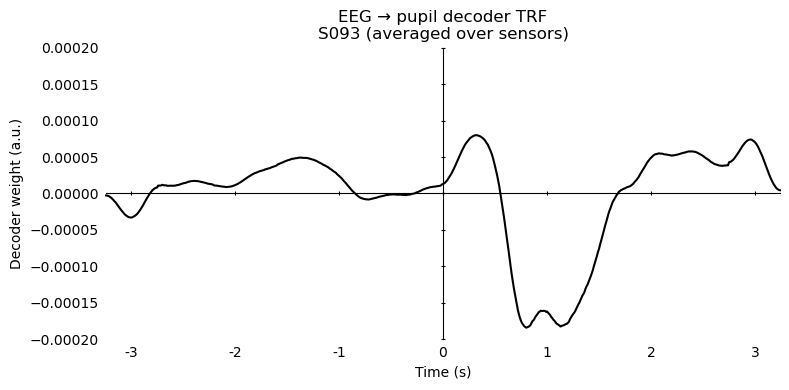

<Figure size 640x480 with 0 Axes>

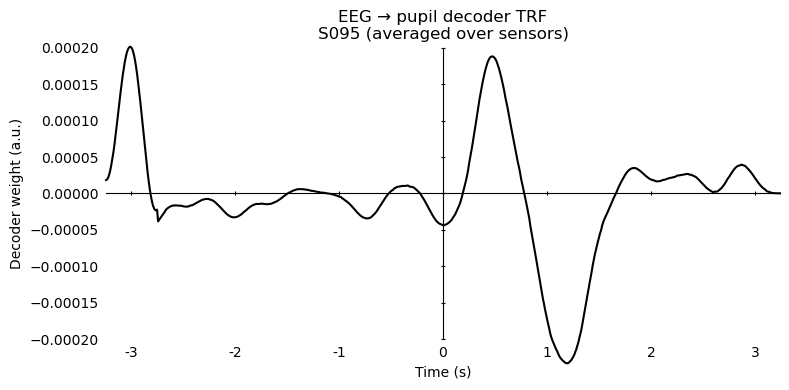

<Figure size 640x480 with 0 Axes>

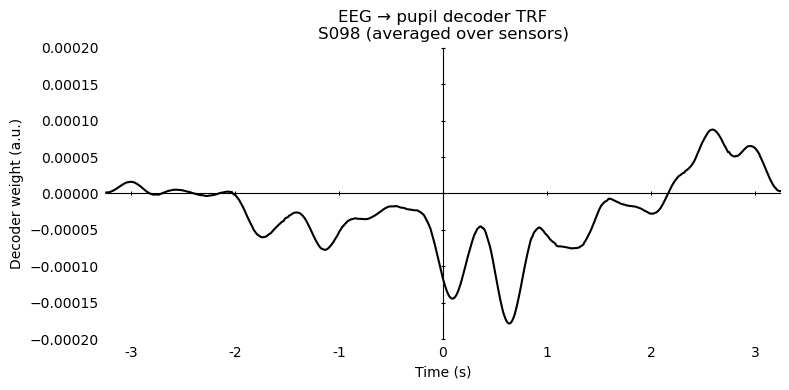

In [9]:
# trf_subj: NDVar(case × time), one TRF per subject (already computed)
trf_subj = trf_all_dec.mean('sensor')

for i, subj_label in enumerate(dataset_dec['subject']):
    plt.figure()
    eelbrain.plot.UTS(
        trf_subj[i],     # NDVar(time) for this subject
        frame='t',
        color='k',
        #linewidth=1.5,
    )
    plt.ylim(-0.0002, 0.0002)  # adjust to your scale   
    plt.title(f"EEG → pupil decoder TRF\n{str(subj_label)} (averaged over sensors)")
    plt.ylabel("Decoder weight (a.u.)")
    plt.xlabel("Time (s)")
    plt.tight_layout()
    # Optional: save instead of (or in addition to) showing
    # out_path = TRF_DIR / f"dec_TRF_{subj_label}.png"
    # plt.savefig(out_path, dpi=150)
    # plt.close()

plt.show()  # if you didn’t close figures in the loop


<Figure size 640x480 with 0 Axes>

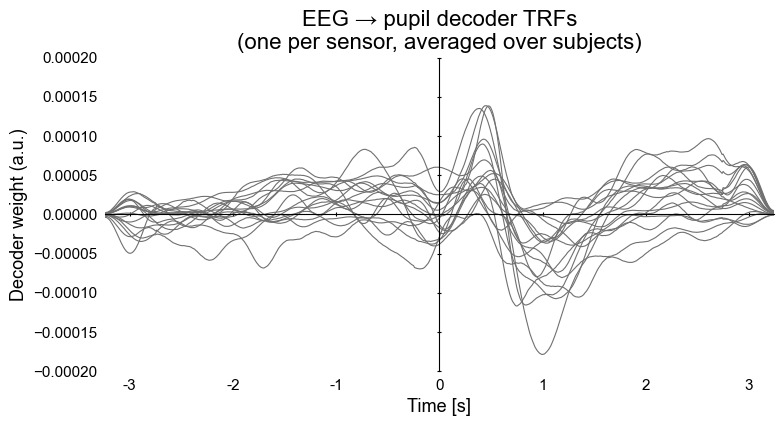

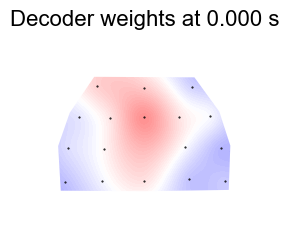

In [29]:
# ------------------------------------------------------------
# 2) TRF per sensor (average over subjects)
# ------------------------------------------------------------
trf_sens = trf_all_dec.mean('case')  # NDVar: sensor × time

plt.figure()
pb_sens = eelbrain.plot.Butterfly(
    trf_sens,
    linewidth=0.8,
    color='#707070',
    frame='t',
    clip=True,
)
plt.title("EEG → pupil decoder TRFs\n(one per sensor, averaged over subjects)")
plt.ylabel("Decoder weight (a.u.)")
plt.ylim(-0.0002, 0.0002)  # adjust to your scale
plt.show()

# pick a time point (in seconds)
latency = 0  # adjust as needed
trf_at_lat = trf_sens.sub(time=latency)

eelbrain.plot.Topomap(
    trf_at_lat,
    vmin=-0.0002,
    vmax=0.00035,
)
plt.title(f"Decoder weights at {latency:.3f} s")
plt.show()



<Figure size 640x480 with 0 Axes>

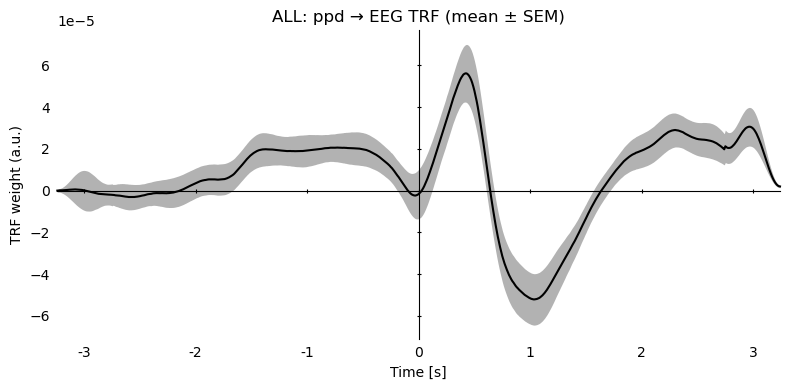

<Figure size 640x480 with 0 Axes>

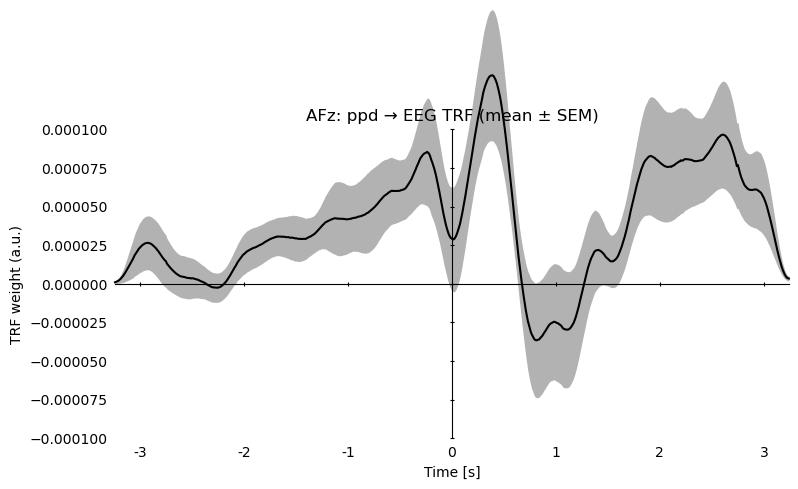

<Figure size 640x480 with 0 Axes>

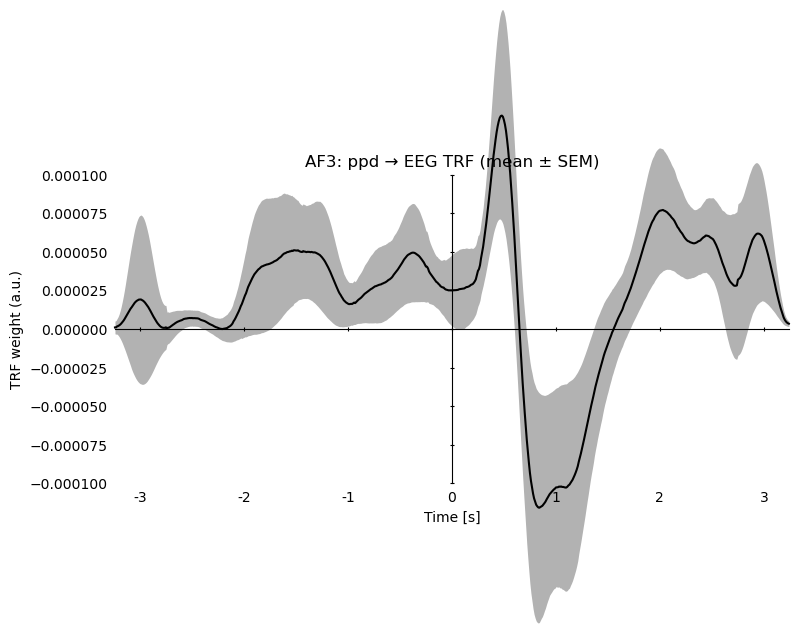

<Figure size 640x480 with 0 Axes>

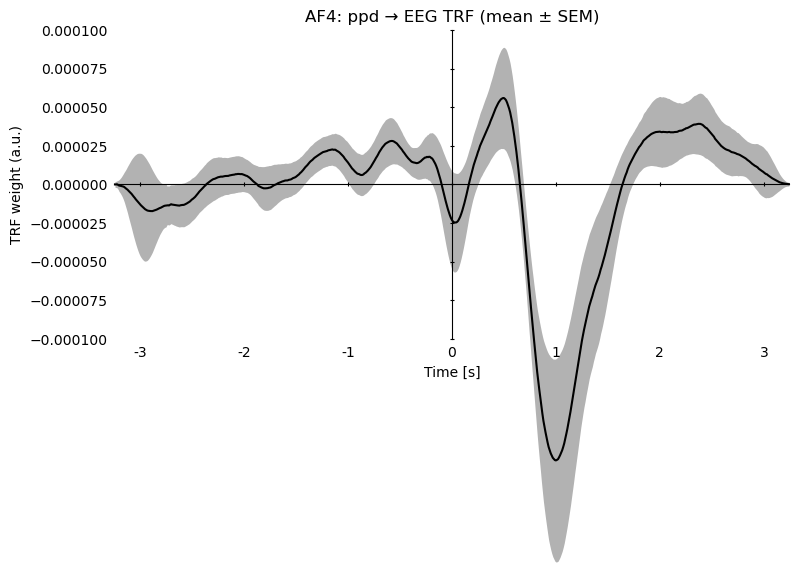

<Figure size 640x480 with 0 Axes>

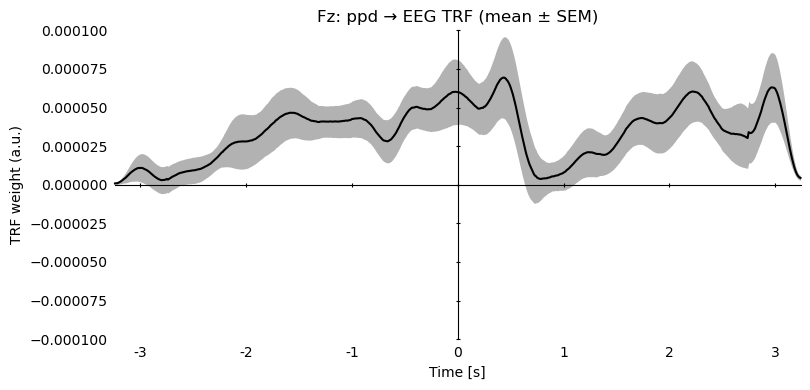

<Figure size 640x480 with 0 Axes>

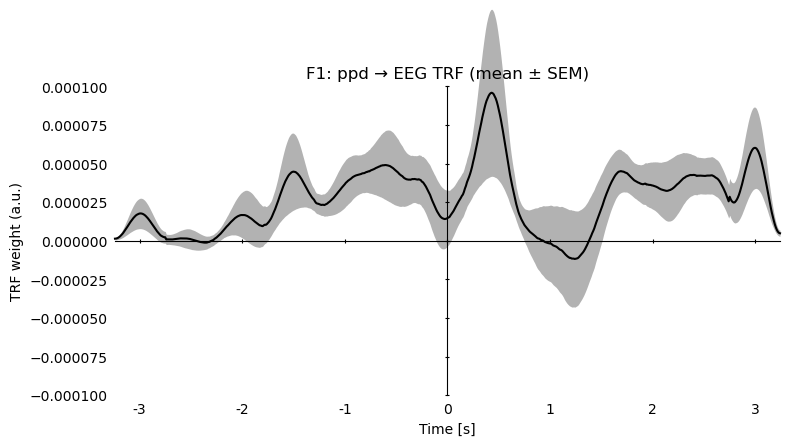

<Figure size 640x480 with 0 Axes>

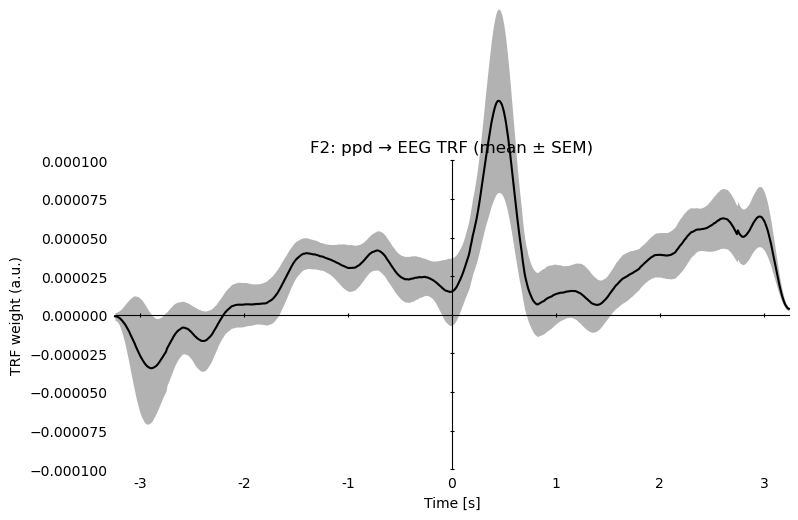

<Figure size 640x480 with 0 Axes>

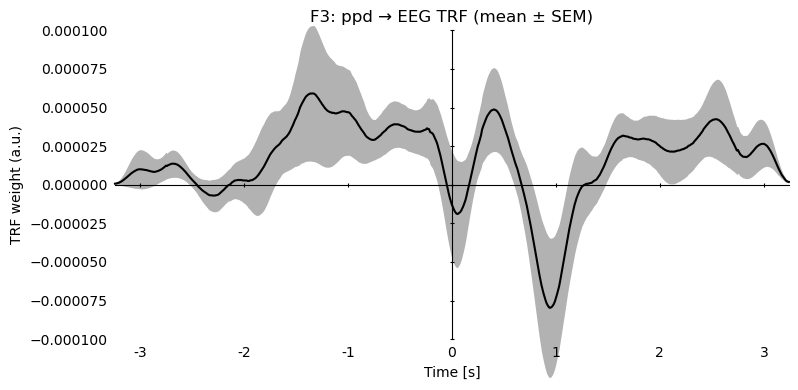

<Figure size 640x480 with 0 Axes>

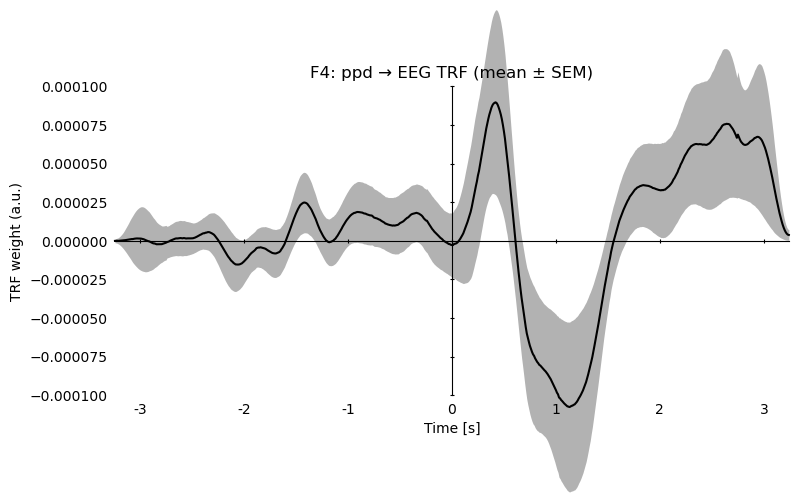

<Figure size 640x480 with 0 Axes>

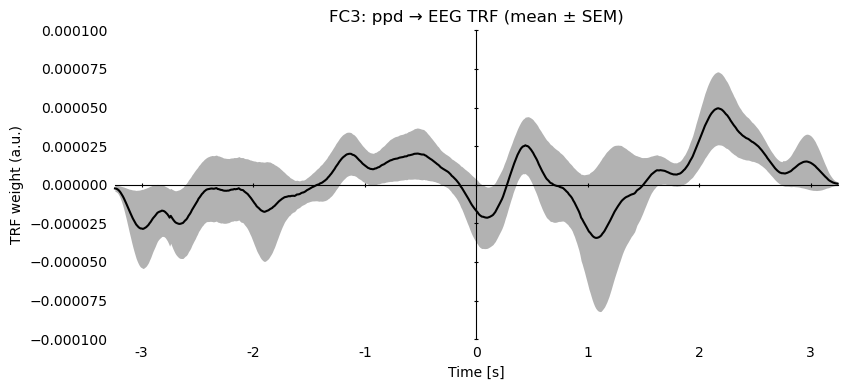

<Figure size 640x480 with 0 Axes>

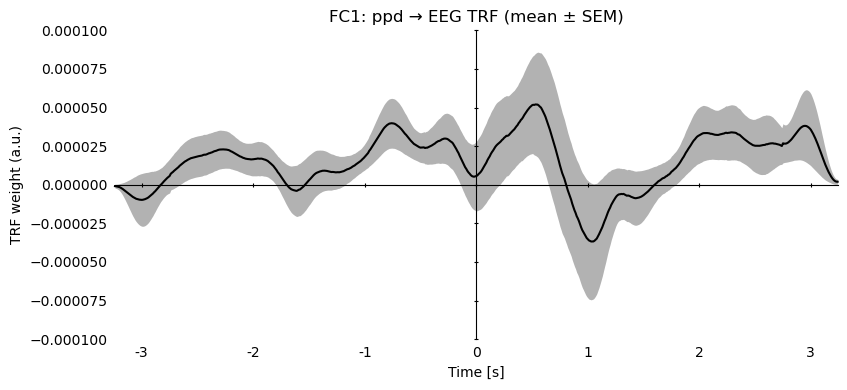

<Figure size 640x480 with 0 Axes>

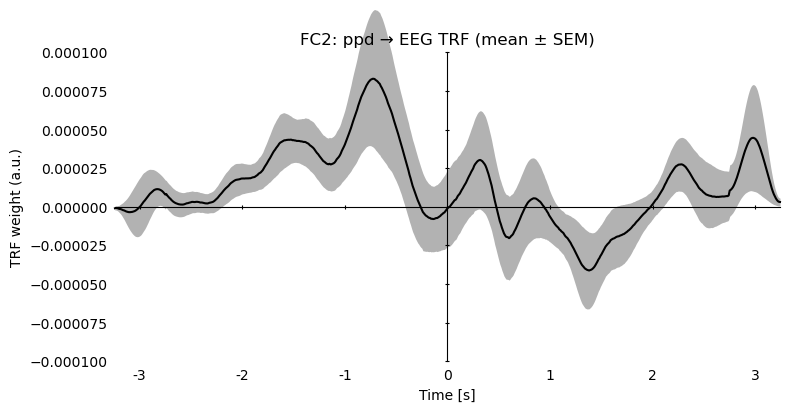

<Figure size 640x480 with 0 Axes>

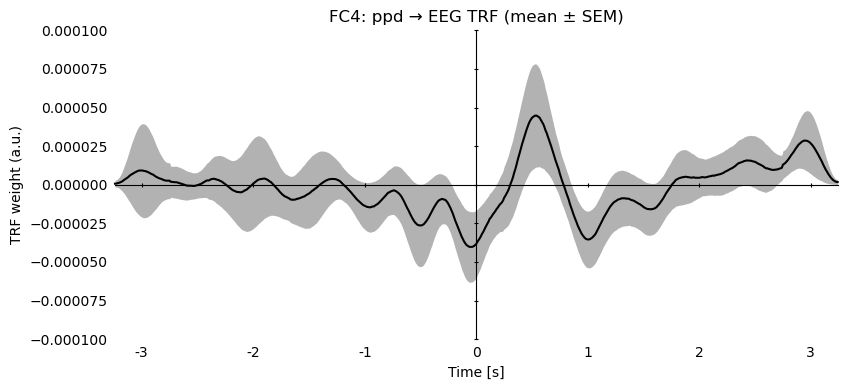

<Figure size 640x480 with 0 Axes>

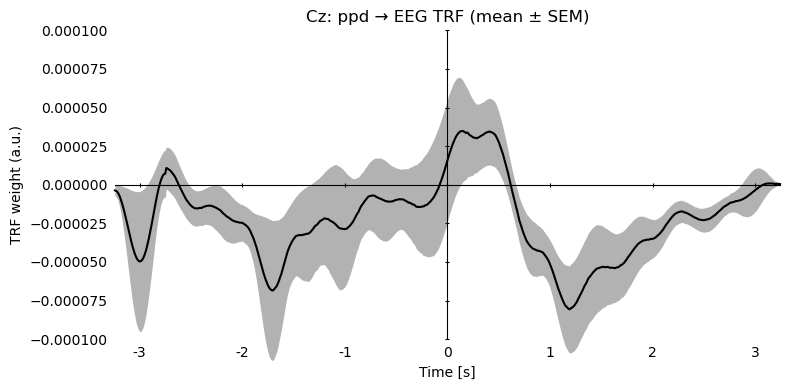

<Figure size 640x480 with 0 Axes>

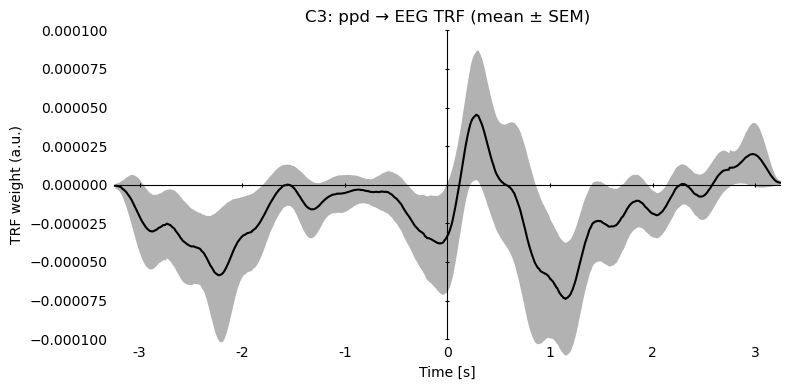

<Figure size 640x480 with 0 Axes>

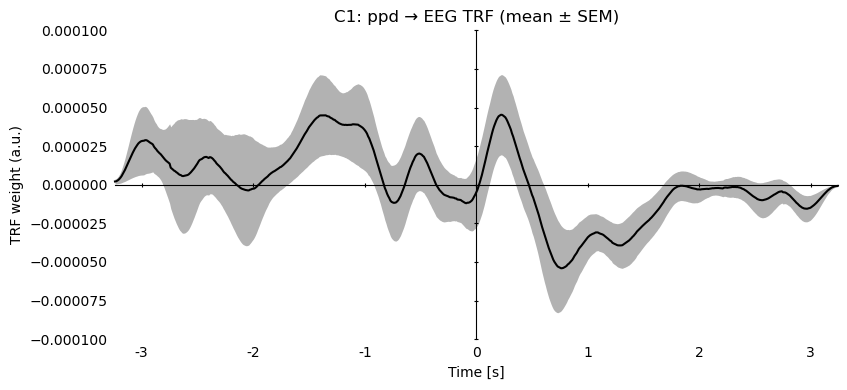

<Figure size 640x480 with 0 Axes>

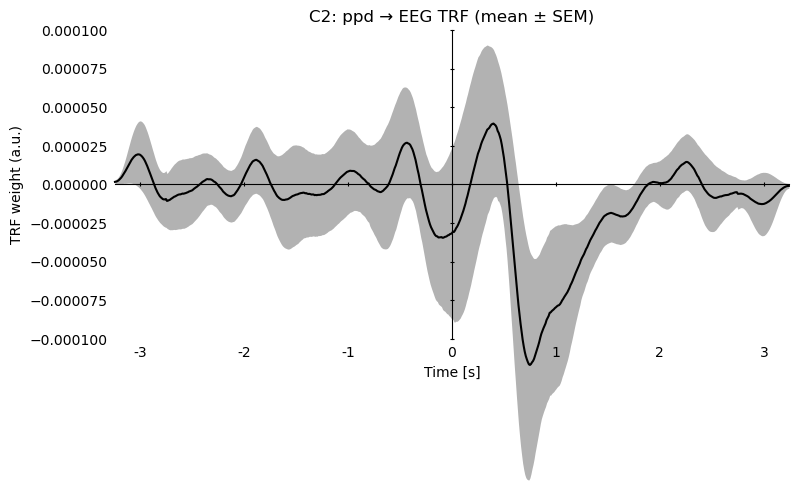

<Figure size 640x480 with 0 Axes>

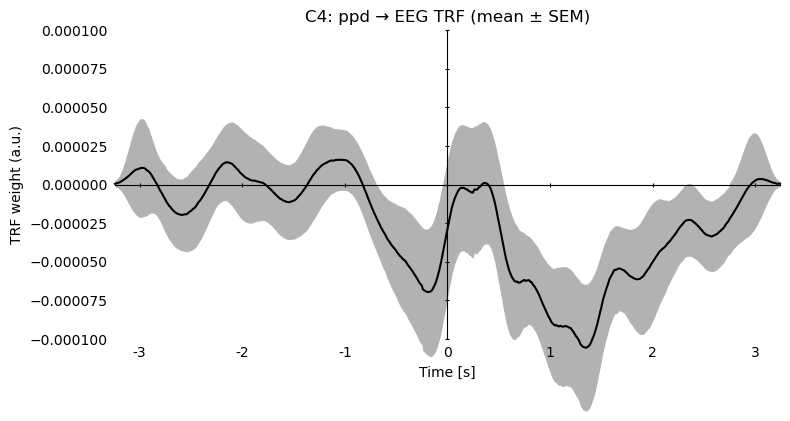

In [11]:
# trf_subj: NDVar(case × time), one TRF per subject (already computed)
trf_sensor = trf_all_dec.mean('sensor')

plt.figure()
eelbrain.plot.UTSStat(
    trf_sensor,
    error='sem',
    frame='t',
    ylabel='TRF weight (a.u.)',
    xlabel='Time [s]',
    axtitle=f"ALL: ppd → EEG TRF (mean ± SEM)",
)
plt.show()

for name in trf_all_dec.sensor:
    trf_s = trf_all_dec.sub(sensor=name)  # case × time

    plt.figure()
    eelbrain.plot.UTSStat(
        trf_s,
        error='sem',
        frame='t',
        ylabel='TRF weight (a.u.)',
        xlabel='Time [s]',
        axtitle=f"{name}: ppd → EEG TRF (mean ± SEM)",
    )
    plt.ylim(-0.0001, 0.0001)  # adjust to your scale
    plt.show()